In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("tmdb (1).xlsx")

In [3]:
print(df.head())

         id    imdb_id  popularity       budget       revenue  \
0  135397.0  tt0369610   32.985763  150000000.0  1.513529e+09   
1   76341.0  tt1392190   28.419936  150000000.0  3.784364e+08   
2  262500.0  tt2908446   13.112507  110000000.0  2.952382e+08   
3  140607.0  tt2488496   11.173104  200000000.0  2.068178e+09   
4  168259.0  tt2820852    9.335014  190000000.0  1.506249e+09   

                 original_title  \
0                Jurassic World   
1            Mad Max: Fury Road   
2                     Insurgent   
3  Star Wars: The Force Awakens   
4                     Furious 7   

                                                cast  \
0  Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...   
1  Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...   
2  Shailene Woodley|Theo James|Kate Winslet|Ansel...   
3  Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...   
4  Vin Diesel|Paul Walker|Jason Statham|Michelle ...   

                                            homepage         

In [4]:
print(df.columns) 

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')


In [5]:
print(df.shape) 

(10869, 21)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10869 entries, 0 to 10868
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  float64
 1   imdb_id               10856 non-null  object 
 2   popularity            10867 non-null  float64
 3   budget                10866 non-null  float64
 4   revenue               10866 non-null  float64
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  float64
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [7]:
print(df.describe())

                  id    popularity        budget       revenue       runtime  \
count   10866.000000  10867.000000  1.086600e+04  1.086600e+04  10866.000000   
mean    66064.177434      1.646289  1.462570e+07  3.982332e+07    102.070863   
std     92130.136561    104.233908  3.091321e+07  1.170035e+08     31.381405   
min         5.000000      0.000065  0.000000e+00  0.000000e+00      0.000000   
25%     10596.250000      0.207591  0.000000e+00  0.000000e+00     90.000000   
50%     20669.000000      0.383880  0.000000e+00  0.000000e+00     99.000000   
75%     75610.000000      0.713994  1.500000e+07  2.400000e+07    111.000000   
max    417859.000000  10866.000000  4.250000e+08  2.781506e+09    900.000000   

         vote_count  vote_average  release_year    budget_adj   revenue_adj  
count  10866.000000  10866.000000  10866.000000  1.086600e+04  1.086600e+04  
mean     217.389748      5.974922   2001.322658  1.755104e+07  5.136436e+07  
std      575.619058      0.935142     12.8129

In [16]:
top_movie = df.loc[df["revenue"].idxmax(), ["original_title", "revenue"]]
print(f"Highest revenue movie: {top_movie['original_title']} (${top_movie['revenue']:,})")


Highest revenue movie: Avatar ($2,781,505,847.0)


In [15]:
avg_budget = df["budget"].mean()
avg_revenue = df["revenue"].mean()
print(f"Average budget: ${avg_budget:,.0f} | Average revenue: ${avg_revenue:,.0f}")


Average budget: $14,625,701 | Average revenue: $39,823,320


In [14]:
top_dir = df.loc[df["revenue"].idxmax(), ["director", "original_title", "revenue"]]
print(f"Highest-grossing movie director: {top_dir['director']} ({top_dir['original_title']})")


Highest-grossing movie director: James Cameron (Avatar)


In [13]:
most_common_genre = df["genres"].mode()[0] if "genres" in df.columns else "N/A"
print(f"Most frequent genre: {most_common_genre}")


Most frequent genre: Comedy


In [17]:
avg_runtime = df["runtime"].mean()
print(f"Average runtime: {avg_runtime:.1f} minutes")

Average runtime: 102.1 minutes


In [29]:
most_voted = df.loc[df["vote_count"].idxmax(), ["original_title", "vote_count"]]
print(f"🔟 Most voted movie: {most_voted['original_title']} ({int(most_voted['vote_count'])} votes)")

🔟 Most voted movie: Inception (9767 votes)


In [19]:
avg_rating_per_year = df.groupby("release_year")["vote_average"].mean().idxmax()
print(f"Year with highest average rating: {avg_rating_per_year}")

Year with highest average rating: 1973.0


In [20]:
longest_movie = df.loc[df["runtime"].idxmax(), ["original_title", "runtime"]]
print(f"Longest movie: {longest_movie['original_title']} ({longest_movie['runtime']} mins)")

Longest movie: The Story of Film: An Odyssey (900.0 mins)


In [21]:
high_rated = (df["vote_average"] > 7.5).sum()
print(f"Movies rated above 7.5: {high_rated}")

Movies rated above 7.5: 350


In [22]:
if "genres" in df.columns:
    avg_pop_by_genre = df.groupby("genres")["popularity"].mean().sort_values(ascending=False)
    print("\nAverage popularity per genre (top 5):")
    print(avg_pop_by_genre.head(5))


Average popularity per genre (top 5):
genres
Adventure|Science Fiction|Thriller                   13.112507
Adventure|Drama|Science Fiction                      12.699699
Science Fiction|Adventure|Thriller                   10.739009
Action|Thriller|Science Fiction|Mystery|Adventure     9.363643
Western|Drama|Adventure|Thriller                      9.110700
Name: popularity, dtype: float64


In [23]:
if "production_companies" in df.columns:
    top_company = df["production_companies"].value_counts().index[0]
    print(f"\nTop production company: {top_company}")


Top production company: Paramount Pictures


In [24]:
if "director" in df.columns:
    top_director = df["director"].value_counts().index[0]
    print(f"Director with most films: {top_director}")

Director with most films: Woody Allen


In [25]:
df["profit"] = df["revenue"] - df["budget"]
profitable = (df["profit"] > 0).mean() * 100
print(f"Percentage of movies that made profit: {profitable:.2f}%")

Percentage of movies that made profit: 34.71%


In [38]:
first_year = int(df["release_year"].min())
last_year = int(df["release_year"].max())
print(f"2️⃣ Movies range from year {first_year} to {last_year}")


2️⃣ Movies range from year 1960 to 2015


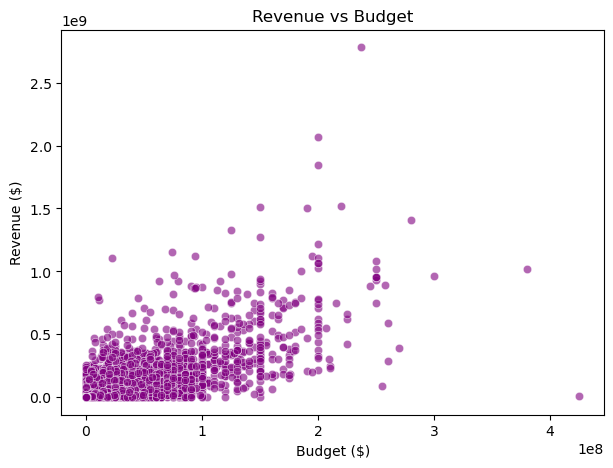

In [40]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.6, color="purple")
plt.title("Revenue vs Budget")
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.show()

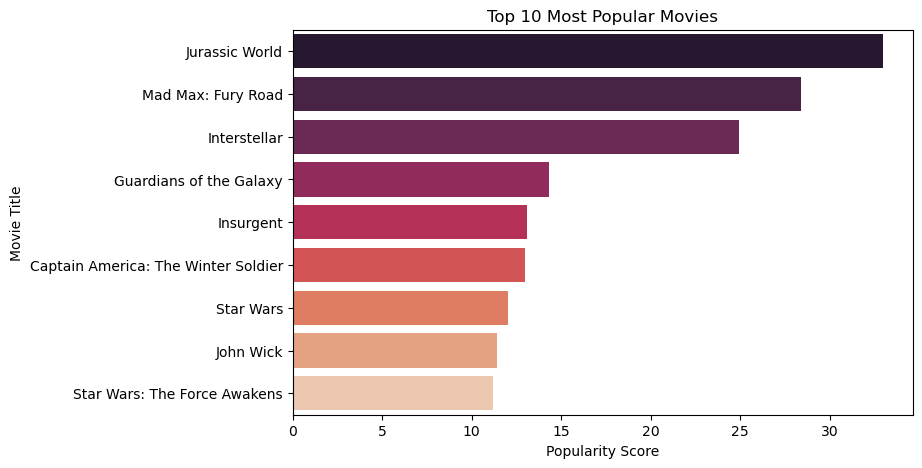

In [10]:
top_popular = df.nlargest(10, "popularity")[["original_title", "popularity"]]
plt.figure(figsize=(8,5))
sns.barplot(data=top_popular, x="popularity", y="original_title", hue="original_title", palette="rocket", legend=False)
plt.title("Top 10 Most Popular Movies")
plt.xlabel("Popularity Score")
plt.ylabel("Movie Title")
plt.show()

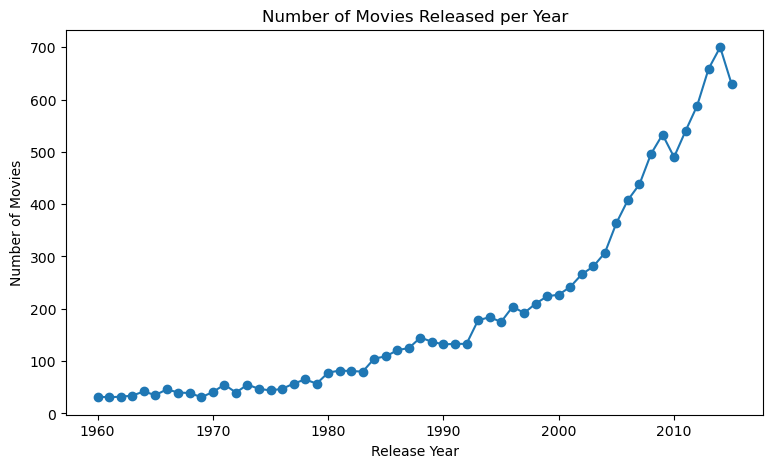

In [11]:
movies_per_year = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(9,5))
movies_per_year.plot(kind="line", marker="o")
plt.title("Number of Movies Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

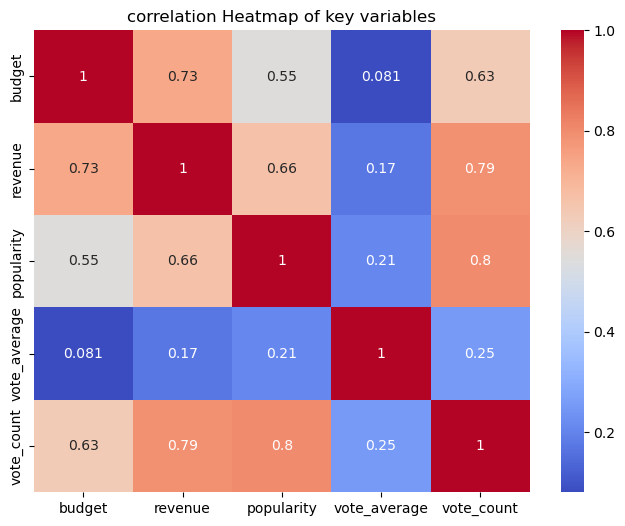

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["budget", "revenue", "popularity", "vote_average", "vote_count"]].corr(), annot=True, cmap="coolwarm")
plt.title("correlation Heatmap of key variables")
plt.show()